In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [1]:
df = pd.read_csv("../data/AmesHousing.csv")

print(df.shape)
df.head()

NameError: name 'pd' is not defined

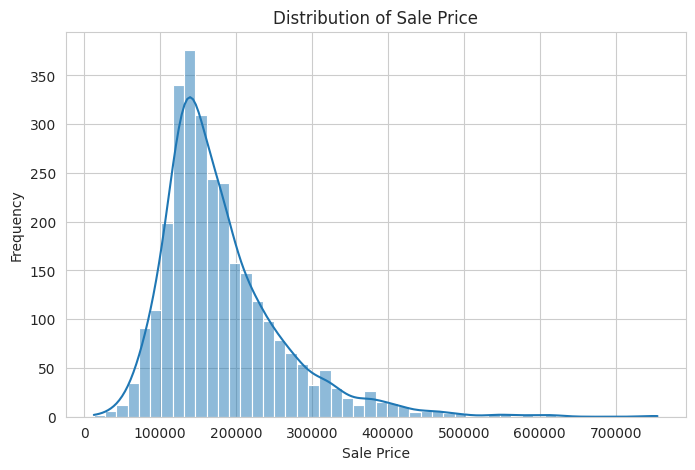

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice"], kde=True, bins=50)
plt.title("Distribution of Sale Price")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.show()

📊 SalePrice Distribution Analysis

    Right-Skewed Distribution: The target variable (SalePrice) shows a strong positive skewness. The vast majority of houses are priced between $100,000 and $200,000, with the peak (mode) sitting around $135,000.

    Presence of a Long Tail: There is a clear "long tail" extending to the right, representing luxury or high-end properties (well above $400,000 and reaching up to over $700,000). These few extreme high values pull the mean upward, making it higher than the median.


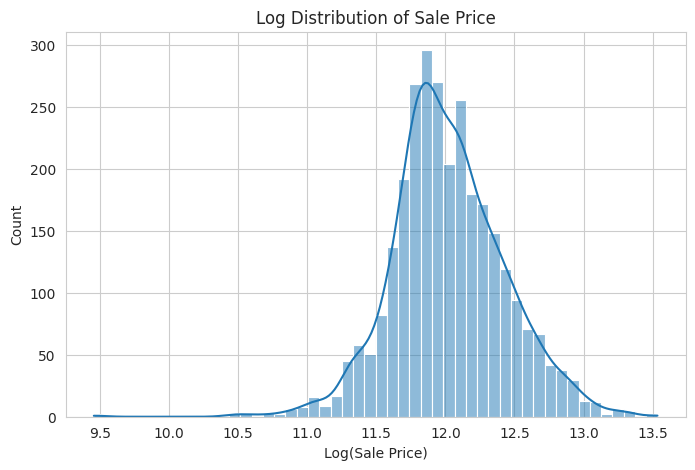

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df["SalePrice"]), kde=True, bins=50)
plt.title("Log Distribution of Sale Price")
plt.xlabel("Log(Sale Price)")
plt.show()

📈 Log-Transformed SalePrice Distribution AnalysisNormal Distribution Approximation: Applying the logarithmic transformation (np.log1p) has successfully converted the highly skewed target variable into a distribution that closely resembles a Normal (Gaussian) distribution.Symmetry and Outlier Mitigation: The long right tail observed in the raw data has been compressed, bringing extreme luxury property prices closer to the center of the distribution. The data is now centered around a log value of approximately $11.9$ (which corresponds to roughly $147,000).



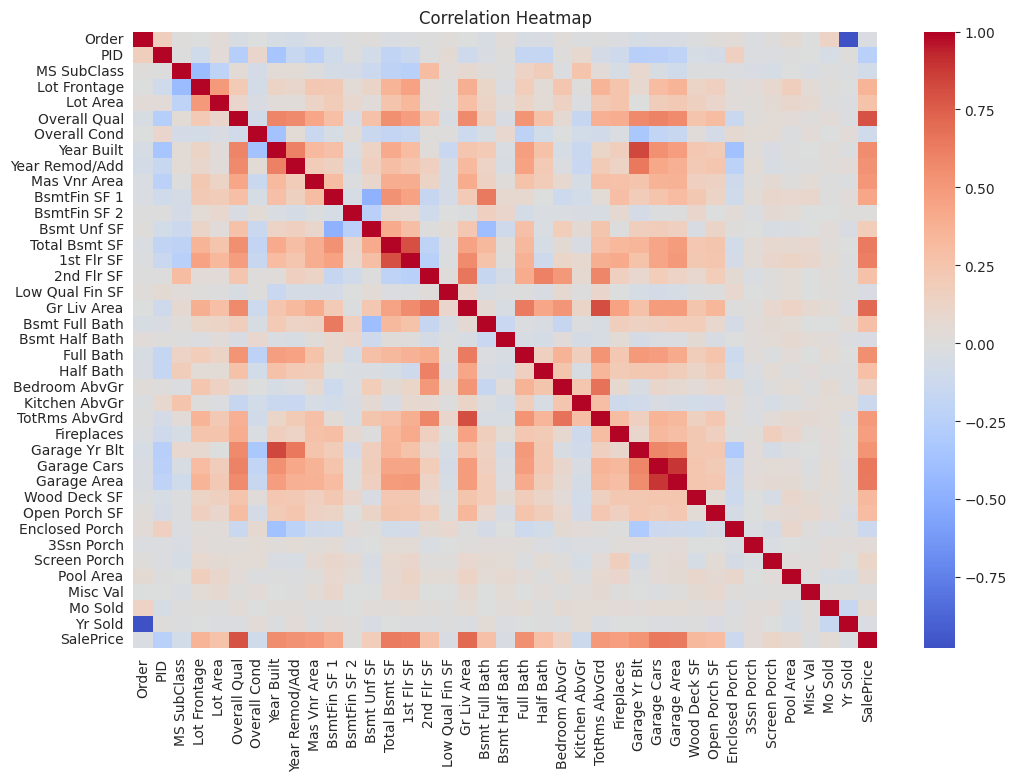

In [17]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


🔥 Correlation Heatmap AnalysisPrimary Price Drivers (Strong Positive Correlation): Looking at the bottom row (SalePrice), several features stand out with intense dark red squares, indicating they have a dominant positive linear relationship with a home's value:Overall Qual (Overall Material and Finish Quality)Gr Liv Area (Above Grade Living Area Square Feet)Total Bsmt SF (Total Basement Square Feet) / 1st Flr SFGarage Cars / Garage AreaIrrelevant and Noise Features (Near-Zero Correlation):Features represented by light grey squares share almost no linear relationship with SalePrice. Identifiers like Order and PID, as well as temporal data like Mo Sold or Yr Sold, show neutral correlations close to $0.0$. These are prime candidates to be dropped from the modeling phase.Multi-Collinearity Warning Signs:There are distinct dark red blocks away from the target row where features correlate heavily with each other. This indicates redundant information:Garage Cars vs Garage Area: They measure essentially the same thing (garage capacity).Total Bsmt SF vs 1st Flr SF: In many architectural designs, the basement footprint directly matches the first floor footprint.Year Built vs Garage Yr Blt: Garages are typically constructed at the same time as the house.


In [18]:
corr_target = corr["SalePrice"].sort_values(ascending=False)

print(corr_target.head(15))

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Mas Vnr Area      0.508285
TotRms AbvGrd     0.495474
Fireplaces        0.474558
BsmtFin SF 1      0.432914
Name: SalePrice, dtype: float64


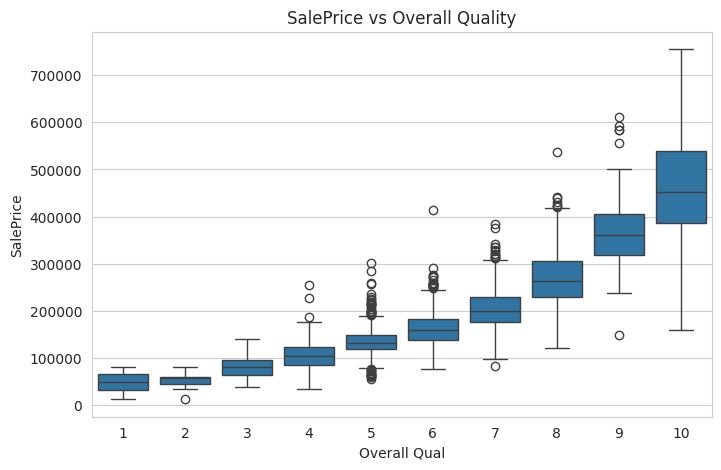

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Overall Qual"], y=df["SalePrice"])
plt.title("SalePrice vs Overall Quality")
plt.show()

📊 SalePrice vs Overall Quality AnalysisNon-Linear Exponential Growth: There is an undeniable, strong positive relationship between the overall material/finish quality (Overall Qual) and the SalePrice. However, the price increase is not strictly linear; it curves upward exponentially. Moving from a quality score of $5$ to $6$ yields a modest price increase, whereas moving from $9$ to $10$ triggers a massive financial premium.Increasing Variance (Heteroscedasticity): As the quality rating climbs, the vertical spread (height) of the boxes expands dramatically. Lower-quality scores ($1$ to $4$) have tightly clustered, predictable pricing. High-quality scores ($8$ to $10$) show massive variance, meaning luxury buyers are willing to pay wildly different premiums for top-tier properties.Intra-Class Outliers: The little circles above and below the boxes indicate properties whose prices deviate significantly from their quality peers. For instance, notice the outliers in quality categories $5$ and $6$ that sold for over $300,000—well above their class median.


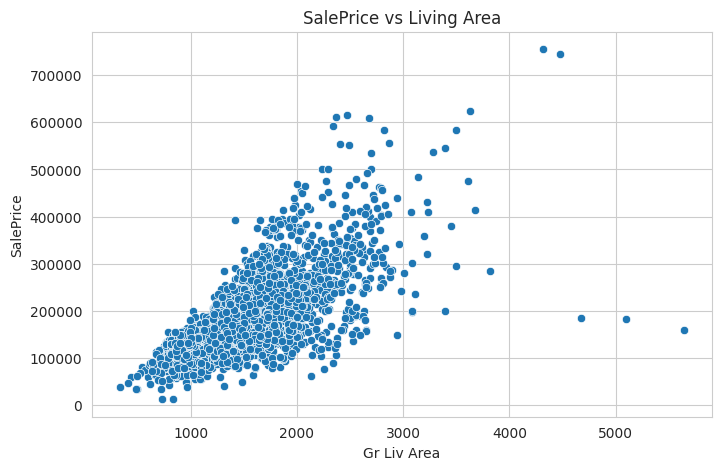

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Gr Liv Area"], y=df["SalePrice"])
plt.title("SalePrice vs Living Area")
plt.show()

📊 SalePrice vs Living Area AnalysisStrong Linear Core Relationship: For the vast majority of the data, there is a clear, tight upward linear trend. As the above-grade living area (Gr Liv Area) increases, the SalePrice rises proportionally. This confirms physical space as one of our strongest continuous predictive features.The "Ames Housing" Anomalies (Extreme Outliers): Look closely at the bottom-right corner of the plot. There are three specific data points with massive living spaces (between $4\,500$ and over $5\,500$ sq ft) that sold for surprisingly low prices (under $200,000).🛠️ Impact on the ML Pipeline (Why this matters)⚠️ The Danger: In linear models, regression lines are heavily influenced by points far away from the mean because the loss function squares the distance of the error. These three properties are not representative of normal real estate market conditions (according to the original data documentation, they were partial, non-standard sales, such as agricultural or family liquidations). Leaving them in will warp your model's weight coefficients, leading to poor generalization.💡 The MLOps Solution (Data Cleaning Code): Before split-training your data, you should explicitly drop these severe outliers using a filtering condition in Pandas.

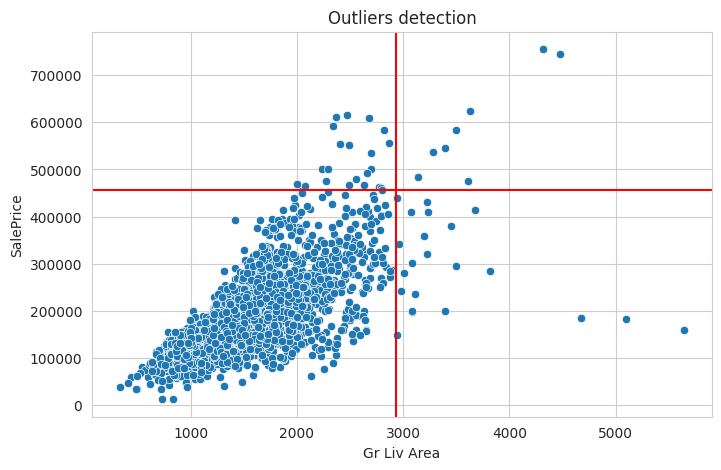

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Gr Liv Area"], y=df["SalePrice"])

plt.axvline(df["Gr Liv Area"].quantile(0.99), color="red")
plt.axhline(df["SalePrice"].quantile(0.99), color="red")

plt.title("Outliers detection")
plt.show()

🚨 Outlier Detection Threshold AnalysisQuadrant Breakdown: By adding these threshold lines, the dataset is split into distinct zones:Top Right: High-end luxury properties that have both massive living spaces and very high price tags. These points follow the general upward trend of the housing market.Bottom Right (The True Anomalies): Properties with over $4\,000$ sq ft of living space that sold for under $200,000. These houses defy normal market economics.🛠️ Impact on the ML Pipeline (Why this matters)⚠️ The Issue with Hard Thresholds: If we use a strict threshold like Gr Liv Area > 2900 or SalePrice > 450000, we risk stripping away the natural variance of the luxury real estate market. Our model needs to see expensive, large houses to understand how to price them.According to the author of the Ames Housing dataset (Dean De Cock), only the houses with more than 4,000 sq ft that show abnormal pricing should be eliminated. The two massive houses at the very top right (~$4\,500$ sq ft at over $700,000) are actually valid data points following the economic trend.